# PmodTMP2 Sensor example

In this example, the Pmod temperature sensor is initialized and will log a reading every 1 second. 

This example requires the PmodTMP2 sensor, and assumes it is attached to PMODB.

### 1. Simple TMP2 read() to see current room temperature

In [1]:
from pynq.overlays.base import BaseOverlay
base = BaseOverlay("base.bit")

In [2]:
%%microblaze base.PMODB
#include <i2c.h>

float get_temperature(){

  i2c device = i2c_open(3, 2);
  
  unsigned char raw_data[2];
  unsigned int sample;
  
  // TMP2 get sample in Celsius (x2 reads to clear stale data)
  i2c_read(device,0x4b,raw_data,2);
  i2c_read(device,0x4b,raw_data,2);
  sample = (raw_data[0] << 8) | raw_data[1];
  return (((float)sample)*0.0625)/8; 
}

In [3]:
print(str(get_temperature()) + " C")

27.25 C


### 2. Starting logging temperature once every second

In [4]:
from time import sleep

results = list()
for _ in range(10):
    results.append(get_temperature())
    sleep(1)

### 3. Try to modify temperature reading by touching the sensor

During this period, try to press finger on the sensor to increase its temperature reading.

### 4. Plot values over time

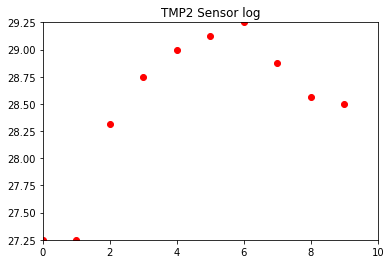

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(range(len(results)), results, 'ro')
plt.title('TMP2 Sensor log')
plt.axis([0, len(results), min(results), max(results)])
plt.show()